In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import polars as pl
from IPython.display import HTML, Image, display

from src import load, filters, typology, inspect, visualize
from src.config import PROCESSED_DIR, SOURCE_COUNTRY, SOURCE_YEAR


In [2]:
lf = load.load_facts_lazy()
load.inspect_schema(lf)

=== Schema ===
  entity_word_id: String
  speech_id: String
  paragraph_id: String
  sentence_id: String
  sentence_content_current: String
  sentence_content_previous: String
  sentence_content_next: String
  sentence_sentiment_value: Float32
  sentence_sentiment_ana: String
  total_tokens_in_speech: Int32
  total_tokens_in_session: Int32
  entity_category: String
  entity_content: String
  country: String
  session_date: Date
  debate_topic: String
  speaker_id: String
  speaker_ana: String

Total rows: 321,404


In [3]:
inspect.show_topic_distribution(lf, top_n=15)

debate_topic,n
str,u32
"""other""",80111
"""macro""",28709
"""mixed""",21182
"""inter""",19400
"""gover""",17159
…,…
"""trans""",12553
"""healt""",11254
"""domes""",10594


In [4]:
mentions = filters.build_migration_mentions(lf)
print(f"Foreign country mentions in {SOURCE_COUNTRY} {SOURCE_YEAR} migration debates: "
      f"{mentions.height:,}")
mentions.head(10)

Foreign country mentions in FRA 2018 migration debates: 1,645


sentence_id,speech_id,session_date,speaker_id,speaker_ana,entity_content,geo_class,region_group,context_window,sentence_content_current,sentence_sentiment_value,sentence_sentiment_ana,debate_topic,country
str,str,date,str,str,str,str,str,str,str,f32,str,str,str
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Croisilles""","""foreign""","""non_european_country""","""I associate my colleagues from…","""The arrival of the President o…",4.765,"""senti:pospos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""United Kingdom""","""foreign""","""european_country""","""As the President of the Republ…","""Respect for the rule of law , …",3.72,"""senti:mixpos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Calais Lande""","""foreign""","""non_european_country""","""Humanity and dignity , finally…","""How can one think that their o…",0.074,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA227076""","""regular""","""London""","""foreign""","""non_european_country""","""Finally , international action…","""The President of the Republic …",2.991,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA227076""","""regular""","""United Kingdom""","""foreign""","""european_country""","""Finally , international action…","""The President of the Republic …",2.991,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""non_european_country""",""" || Madam President , Minister…","""Madam President , Minister of …",1.212,"""senti:mixneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""European Union""","""european_union""","""european_union""","""Madam President , Minister of …","""As a result , the European Uni…",3.742,"""senti:mixpos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""non_european_country""","""As a result , the European Uni…","""Last November , you remember ,…",0.42,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""non_european_country""","""It is easy to say that we want…","""But it is even easier to send …",0.179,"""senti:negneg""","""immig""","""FRA"""


In [5]:
top = inspect.show_top_countries(mentions, top_n=20)
top

entity_content,n_mentions,geo_class,region_group,avg_sentiment,std_sentiment,min_sentiment,max_sentiment
str,u32,str,str,f32,f32,f32,f32
"""Mayotte""",211,"""french_overseas""","""french_overseas""",1.239,1.438,-0.111,5.075
"""European Union""",152,"""european_union""","""european_union""",1.642,1.447,-0.125,5.174
"""United Kingdom""",84,"""foreign""","""european_country""",1.51,1.37,0.05,4.773
"""Italy""",76,"""foreign""","""european_country""",1.252,1.197,-0.077,4.817
"""Germany""",66,"""foreign""","""european_country""",1.499,1.264,0.07,4.835
…,…,…,…,…,…,…,…
"""Hungary""",16,"""foreign""","""european_country""",1.129,1.45,-0.027,4.76
"""Turkey""",16,"""foreign""","""non_european_country""",1.106,1.217,0.081,3.979
"""Lebanon""",12,"""foreign""","""non_european_country""",2.062,1.167,0.073,3.305


In [6]:
annotated = typology.apply_typology(mentions)

# Explanation: sentiment_level keeps the original 6-level ParlaMint label.
# Explanation: sentiment_readable is only a clearer label for tables and charts.
annotated.select([
    "entity_content",
    "ref_type",
    "sentiment_level",
    "sentiment_readable",
    "sentiment_polarity",
    "sentence_sentiment_value",
]).head(10)


entity_content,ref_type,sentiment_level,sentiment_readable,sentiment_polarity,sentence_sentiment_value
str,str,str,str,str,f32
"""Croisilles""","""mixed""","""senti:pospos""","""strong pos""","""positive""",4.765
"""United Kingdom""","""policy""","""senti:mixpos""","""mixed pos""","""positive""",3.72
"""Calais Lande""","""situation""","""senti:negneg""","""strong neg""","""negative""",0.074
"""London""","""policy""","""senti:neupos""","""neutral pos""","""neutral""",2.991
"""United Kingdom""","""policy""","""senti:neupos""","""neutral pos""","""neutral""",2.991
"""Libya""","""mixed""","""senti:mixneg""","""mixed neg""","""negative""",1.212
"""European Union""","""mixed""","""senti:mixpos""","""mixed pos""","""positive""",3.742
"""Libya""","""mixed""","""senti:negneg""","""strong neg""","""negative""",0.42
"""Libya""","""situation""","""senti:negneg""","""strong neg""","""negative""",0.179


In [7]:
# Explanation: This is now a 4 x 6 matrix: reference type x ParlaMint sentiment level.
matrix = typology.build_matrix(annotated)
matrix


ref_type,senti:negneg,senti:mixneg,senti:neuneg,senti:neupos,senti:mixpos,senti:pospos
str,u32,u32,u32,u32,u32,u32
"""mixed""",159,80,34,51,48,11
"""policy""",254,122,156,112,52,10
"""situation""",165,68,59,57,34,10
"""neutral_reference""",59,29,22,40,7,6


In [8]:
top_5_countries = top.head(5)["entity_content"].to_list()
country_matrix = typology.matrix_by_country(
    annotated.filter(pl.col("entity_content").is_in(top_5_countries)),
    min_mentions=3,
)
country_matrix

entity_content,ref_type,sentiment_level,n
str,str,str,u32
"""European Union""","""mixed""","""senti:mixneg""",5
"""European Union""","""mixed""","""senti:mixpos""",7
"""European Union""","""mixed""","""senti:negneg""",20
"""European Union""","""mixed""","""senti:neuneg""",4
"""European Union""","""mixed""","""senti:neupos""",8
…,…,…,…
"""United Kingdom""","""policy""","""senti:neuneg""",8
"""United Kingdom""","""policy""","""senti:neupos""",9
"""United Kingdom""","""situation""","""senti:mixneg""",5


In [9]:
# Look at Germany mentions - read 5 random ones and check whether the
# heuristic classification matches your reading
inspect.show_sample_contexts(annotated, country="Germany", n_samples=5)

session_date,entity_content,ref_type,sentiment_level,sentiment_readable,sentence_sentiment_value,context_window
date,str,str,str,str,f32,str
2018-04-21,"""Germany""","""policy""","""senti:neupos""","""neutral pos""",2.877,"""The Minister of State said tha…"
2018-04-17,"""Germany""","""neutral_reference""","""senti:pospos""","""strong pos""",4.835,"""Tunisia , without a doubt ; Le…"
2018-08-01,"""Germany""","""policy""","""senti:negneg""","""strong neg""",0.323,"""So imagine some cases , absurd…"
2018-04-21,"""Germany""","""mixed""","""senti:mixneg""","""mixed neg""",0.587,"""Indeed , the maximum length of…"
2018-04-21,"""Germany""","""situation""","""senti:mixpos""","""mixed pos""",4.157,"""This amendment , tabled by my …"


In [10]:
inspect.show_sample_contexts(annotated, country="Italy", n_samples=5)

session_date,entity_content,ref_type,sentiment_level,sentiment_readable,sentence_sentiment_value,context_window
date,str,str,str,str,f32,str
2018-07-19,"""Italy""","""situation""","""senti:neuneg""","""neutral neg""",2.194,"""The Constitutional Council too…"
2018-04-17,"""Italy""","""policy""","""senti:negneg""","""strong neg""",0.366,"""Malik Nurulain , says Nour , a…"
2018-11-06,"""Italy""","""policy""","""senti:neupos""","""neutral pos""",3.042,"""Otherwise , it would be right …"
2018-06-13,"""Italy""","""mixed""","""senti:mixneg""","""mixed neg""",1.474,"""We are also present , together…"
2018-07-25,"""Italy""","""policy""","""senti:pospos""","""strong pos""",4.817,"""But what is this populist lepr…"


In [11]:
inspect.show_sample_contexts(annotated, country="Hungary", n_samples=5)

session_date,entity_content,ref_type,sentiment_level,sentiment_readable,sentence_sentiment_value,context_window
date,str,str,str,str,f32,str
2018-04-19,"""Hungary""","""policy""","""senti:neuneg""","""neutral neg""",2.471,"""What is considered a crime in …"
2018-04-10,"""Hungary""","""situation""","""senti:neupos""","""neutral pos""",3.411,""" || Last Sunday , Mr Latomb , …"
2018-08-01,"""Hungary""","""policy""","""senti:negneg""","""strong neg""",0.137,"""Another liberticide effect of …"
2018-04-19,"""Hungary""","""policy""","""senti:mixneg""","""mixed neg""",0.763,"""Let us look , for example , at…"
2018-08-01,"""Hungary""","""policy""","""senti:negneg""","""strong neg""",0.008,"""If he refuses , he may be subj…"


In [12]:
out_path = PROCESSED_DIR / f"{SOURCE_COUNTRY}_{SOURCE_YEAR}_migration_mentions.parquet"
annotated.write_parquet(out_path)
print(f"Saved {annotated.height:,} rows to {out_path}")

Saved 1,645 rows to /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2018_migration_mentions.parquet


/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/reference_type_sentiment_heatmap.png


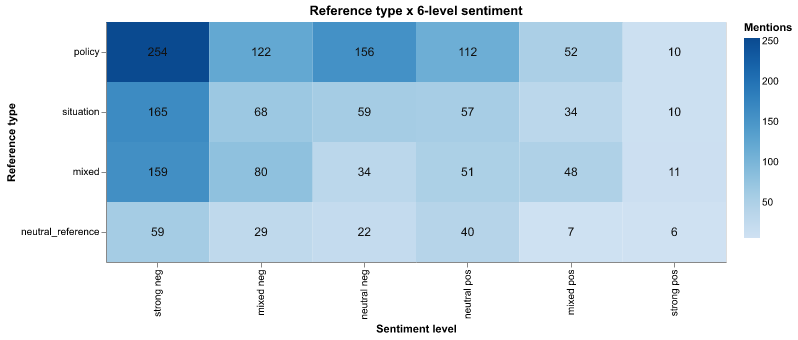

In [13]:
# Explanation: Save the headline 4 x 6 reference-type x sentiment heatmap as Vega-Altair.
headline_heatmap_path = visualize.plot_4x6_heatmap(
    matrix,
    PROCESSED_DIR / "figures_altair" / "reference_type_sentiment_heatmap.png",
)
print(headline_heatmap_path)

# Explanation: Altair always saves an interactive HTML version beside the PNG.
display(Image(filename=str(headline_heatmap_path)))


In [14]:
# Explanation: Show the entities used in the "everything over 25 mentions" visualization.
# Explanation: "More than 25" is implemented as min_mentions=26.
with pl.Config(tbl_rows=100, tbl_cols=10, fmt_str_lengths=80):
    significant_entity_distribution = inspect.country_distribution(annotated, min_mentions=26)
    display(significant_entity_distribution)


entity_content,geo_class,region_group,n_mentions,share_percent
str,str,str,u32,f64
"""Mayotte""","""french_overseas""","""french_overseas""",211,12.83
"""European Union""","""european_union""","""european_union""",152,9.24
"""United Kingdom""","""foreign""","""european_country""",84,5.11
"""Italy""","""foreign""","""european_country""",76,4.62
"""Germany""","""foreign""","""european_country""",66,4.01
"""Comoros""","""foreign""","""non_european_country""",63,3.83
"""French Guiana""","""french_overseas""","""french_overseas""",47,2.86
"""Libya""","""foreign""","""non_european_country""",41,2.49
"""Spain""","""foreign""","""european_country""",29,1.76


## Vega-Altair country visualizations

These figures show how foreign countries, the European Union, and French overseas territories are mentioned in French migration debates. The charts are built with Vega-Altair and saved to `data/processed/figures_altair/` as interactive `.html`, Vega-Lite `.vl.json`, and `.png` files. The top-country charts show the first 10 entities; the fuller distribution and heatmaps show every entity with more than 25 mentions (`n_mentions >= 26`).


In [15]:
# Explanation: Save top-10 visualizations and an "all entities over 25 mentions" view.
# Explanation: "Over 25" means n_mentions >= 26.
figure_paths = visualize.save_all_figures(
    annotated,
    processed_dir=PROCESSED_DIR,
    top_n=10,
    min_mentions_for_all=26,
)

# Explanation: Printing the paths makes it easy for colleagues to find the files.
figure_paths


{'entity_distribution_top10': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_top10.png'),
 'entity_distribution_min26': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_min26.png'),
 'entity_distribution_min26_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_min26.csv'),
 'entity_distribution_all_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_all_for_audit.csv'),
 'reference_type_sentiment_heatmap': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/reference_type_sentime

entity_distribution_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_top10.png


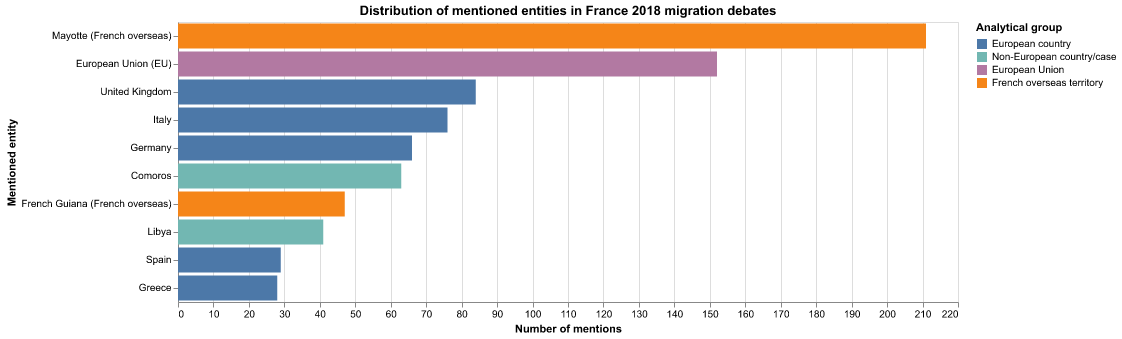

entity_distribution_min26: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_min26.png


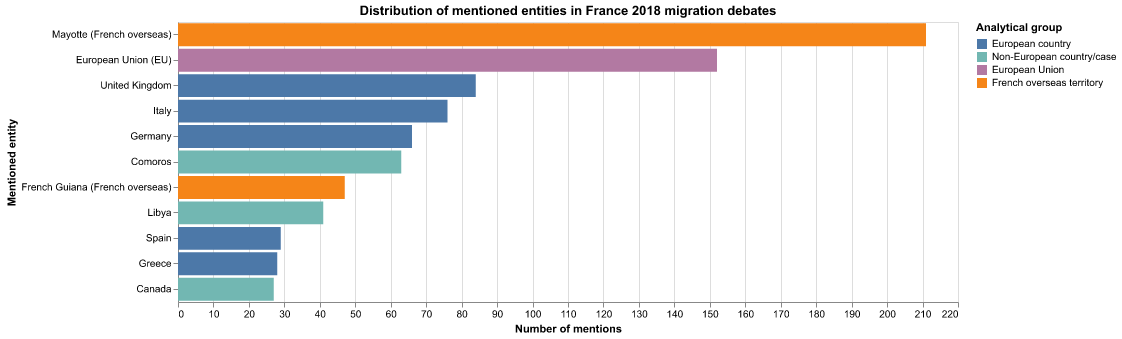

entity_distribution_min26_csv: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_min26.csv
entity_distribution_all_csv: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_all_for_audit.csv
reference_type_sentiment_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/reference_type_sentiment_heatmap.png


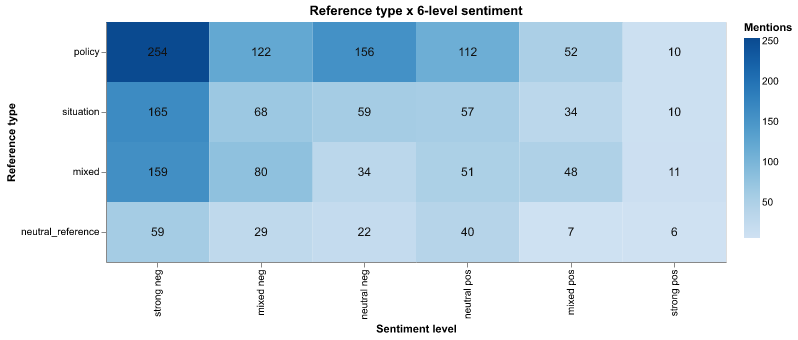

country_sentiment_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_sentiment_mentions_top10.png


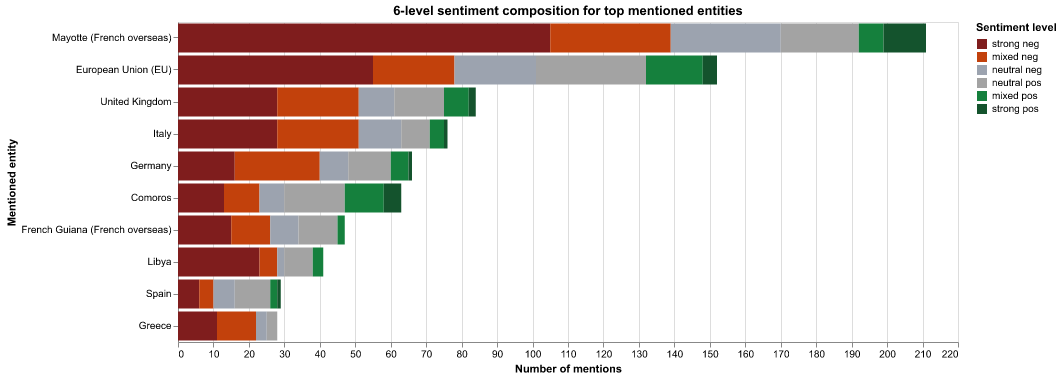

entity_sentiment_heatmap_min26: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_sentiment_heatmap_min26.png


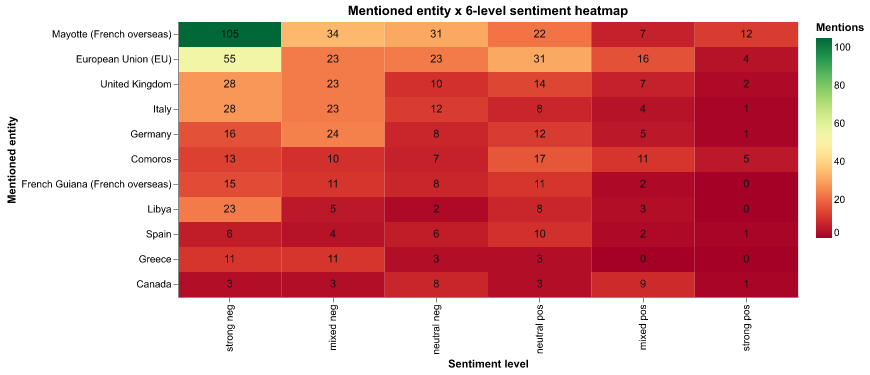

entity_distribution_heatmap_min26: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_heatmap_min26.png


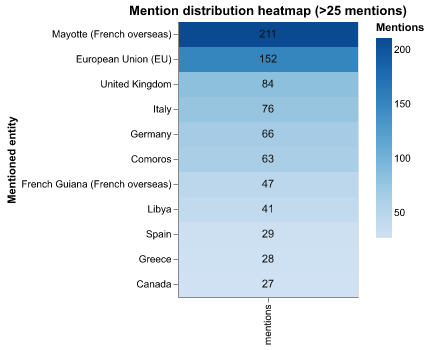

country_reference_type_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_reference_type_mentions_top10.png


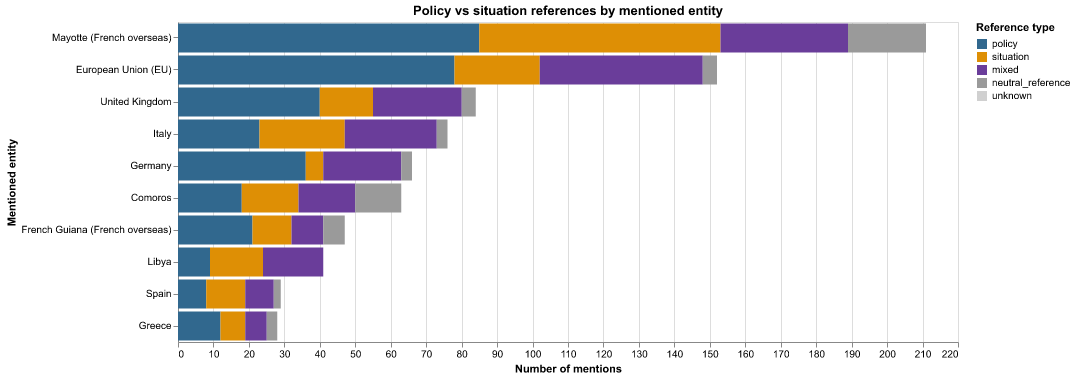

policy_vs_situation_sentiment_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/policy_vs_situation_sentiment_top10.png


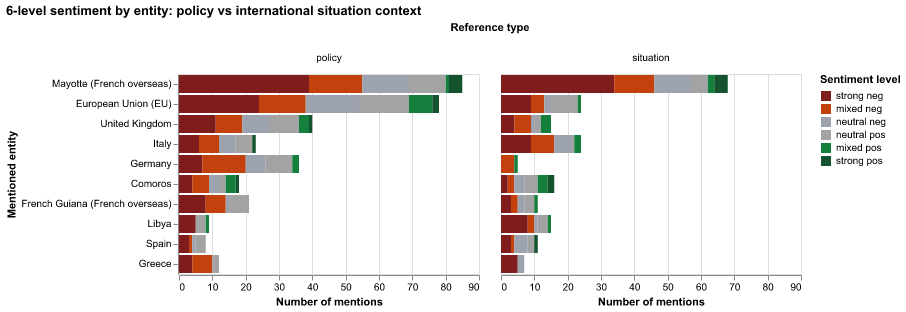

policy_situation_sentiment_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/policy_situation_sentiment_heatmap.png


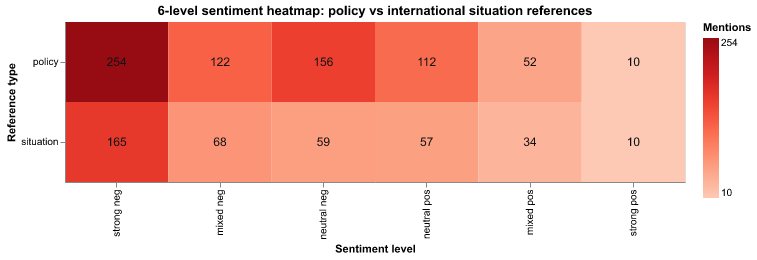

region_group_distribution: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/region_group_distribution.png


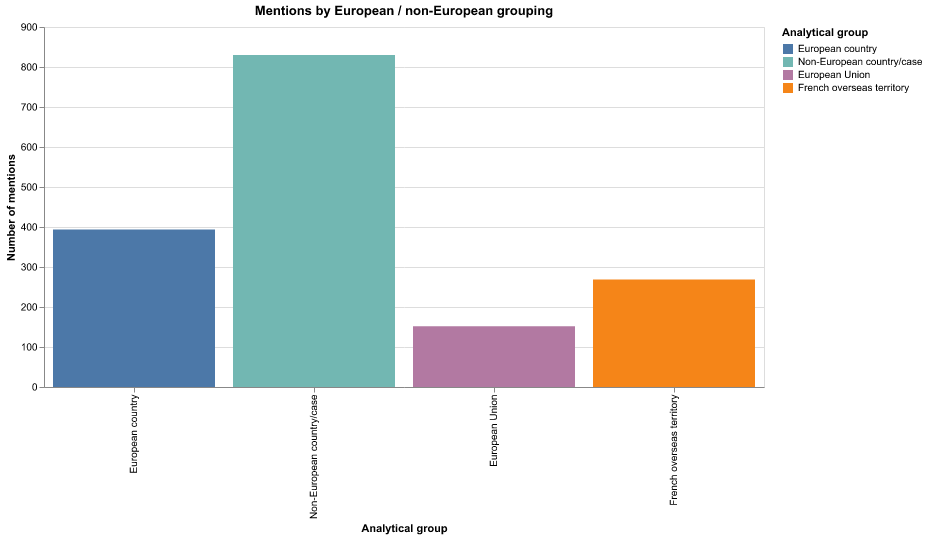

region_group_sentiment: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/region_group_sentiment.png


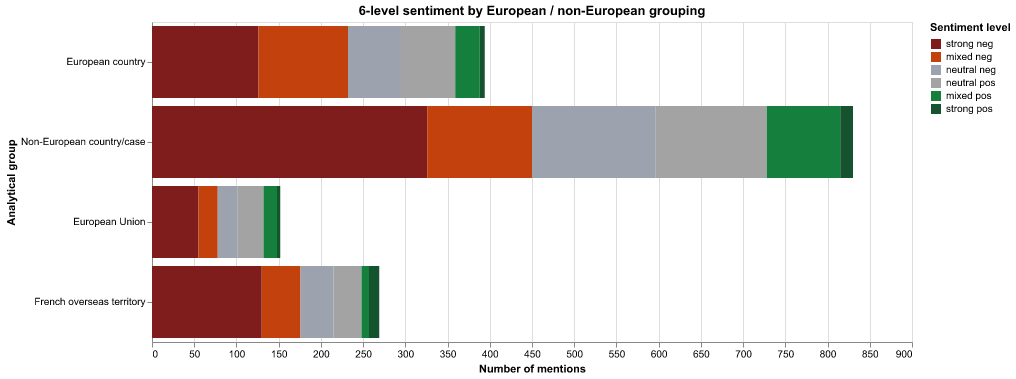

reference_heatmap_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_reference_heatmap_top10.png


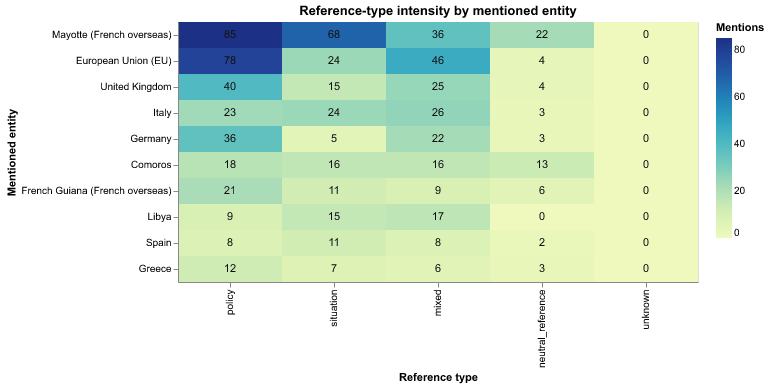


Interactive HTML files:
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_reference_heatmap_top10.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_reference_type_mentions_top10.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/country_sentiment_mentions_top10.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_heatmap_min26.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_distribution_min26.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair/entity_

In [16]:
# Explanation: Display saved PNG figures inline and print every output path.
# Explanation: Interactive HTML files are saved beside each PNG in figures_altair/.
for output_name, output_path in figure_paths.items():
    print(f"{output_name}: {output_path}")
    if str(output_path).endswith(".png"):
        display(Image(filename=str(output_path)))

print("\nInteractive HTML files:")
for html_path in sorted((PROCESSED_DIR / "figures_altair").glob("*.html")):
    print(html_path)


In [17]:
# Explanation: Compact top-10 table for slides or notes.
# Explanation: The displayed distribution above uses the >25 mention threshold.
country_visual_summary = inspect.show_top_countries(annotated, top_n=10, min_mentions=5)
country_visual_summary


entity_content,n_mentions,geo_class,region_group,avg_sentiment,std_sentiment,min_sentiment,max_sentiment
str,u32,str,str,f32,f32,f32,f32
"""Mayotte""",211,"""french_overseas""","""french_overseas""",1.239,1.438,-0.111,5.075
"""European Union""",152,"""european_union""","""european_union""",1.642,1.447,-0.125,5.174
"""United Kingdom""",84,"""foreign""","""european_country""",1.51,1.37,0.05,4.773
"""Italy""",76,"""foreign""","""european_country""",1.252,1.197,-0.077,4.817
"""Germany""",66,"""foreign""","""european_country""",1.499,1.264,0.07,4.835
"""Comoros""",63,"""foreign""","""non_european_country""",2.284,1.533,-0.027,4.975
"""French Guiana""",47,"""french_overseas""","""french_overseas""",1.484,1.254,0.013,4.229
"""Libya""",41,"""foreign""","""non_european_country""",1.213,1.371,-0.013,4.12
"""Spain""",29,"""foreign""","""european_country""",2.044,1.325,0.105,4.915
